# Libreria


In [113]:
import struct
import os
import zipfile
import random

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Optuna
import optuna

# Preprocesamiento de datos
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error

# Copy
import copy

# Manejo de desbalance de clases
from imblearn.over_sampling import SMOTE


# Construcción de la Red Neuronal (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Métricas de evaluación
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, ConfusionMatrixDisplay,fbeta_score)

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Verificar si hay GPU disponible para PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Librerías importadas. PyTorch utilizará el dispositivo: {device}")

Librerías importadas. PyTorch utilizará el dispositivo: cpu


**Carga del dataset**

In [114]:
csv_path = "./superstore.csv"
file_id = "1pdDfYNii7NIPdfQTo2S-rRKfEjGcrr5_"
if not os.path.exists(csv_path):
    print("Descargando dataset...")
    url = f'https://drive.google.com/uc?id={file_id}'
    gdown.download(url, csv_path, quiet=False)
else:
    print("Dataset ya existe, omitiendo descarga.")

Dataset ya existe, omitiendo descarga.


**Definición de semilla**

In [115]:
# Definir una semilla global
SEED = 20
# Configurar NumPy
np.random.seed(SEED)
# Configurar PyTorch (CPU y GPU)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED) # Para multi-GPU
    # Garantizar algoritmos deterministas (puede impactar ligeramente el rendimiento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def fijar_semillas(seed=42):
    """
    Fija las semillas de todos los generadores aleatorios para asegurar reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False

# EDA

### Exploración de los tipos de datos y que contienen cada variable.

In [116]:
dataset = pd.read_csv("./superstore.csv", encoding='Latin-1')

data = dataset.copy()

# Se reemplazan los espacios en los nombres de las columnas
data.columns = data.columns.str.replace(' ', '_')

data.head(5)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [117]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   str    
 2   Order_Date     9994 non-null   str    
 3   Ship_Date      9994 non-null   str    
 4   Ship_Mode      9994 non-null   str    
 5   Customer_ID    9994 non-null   str    
 6   Customer_Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal_Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product_ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product_Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [118]:
print(data.isnull().sum())

Row_ID           0
Order_ID         0
Order_Date       0
Ship_Date        0
Ship_Mode        0
Customer_ID      0
Customer_Name    0
Segment          0
Country          0
City             0
State            0
Postal_Code      0
Region           0
Product_ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


**Eliminación de duplicados**

In [119]:
data = data[data.duplicated() != True]

print(data.duplicated().sum())

0


In [120]:
data.drop(columns=['Row_ID', 'Order_ID', 'Customer_ID', 'Product_ID', 'Customer_Name', 'Product_Name', 'Country', 'City', 'Postal_Code', 'State'], inplace=True)

Criterios de eliminación de variables:

**1. Identificadores únicos (IDs)**

Las variables `Row_ID`, `Order_ID`, `Customer_ID` y `Product_ID` corresponden a identificadores únicos o casi únicos por registro. Estas variables no aportan información predictiva relevante, ya que no contienen patrones generalizables, sino que únicamente permiten distinguir observaciones individuales. Además, su inclusión puede inducir *overfitting* en el modelo.

**2. Variables altamente cardinales y no informativas**

Las variables `Customer_Name` y `Product_Name` presentan una cardinalidad muy elevada y funcionan principalmente como etiquetas descriptivas.   

**3. Variables geográficas poco útiles o redundantes**

`Country` es constante en todo el dataset, por lo que no aporta variabilidad ni capacidad explicativa. `City`, `State` y `Postal_Code` presentan alta cardinalidad, lo que dificulta su codificación. En este sentido, se decide conservar `Region`, ya que constituye una agregación geográfica más general, con menor cardinalidad y mayor potencial explicativo.

In [121]:
data.describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


### **Distribución de la Variable Objetivo (Profit)**

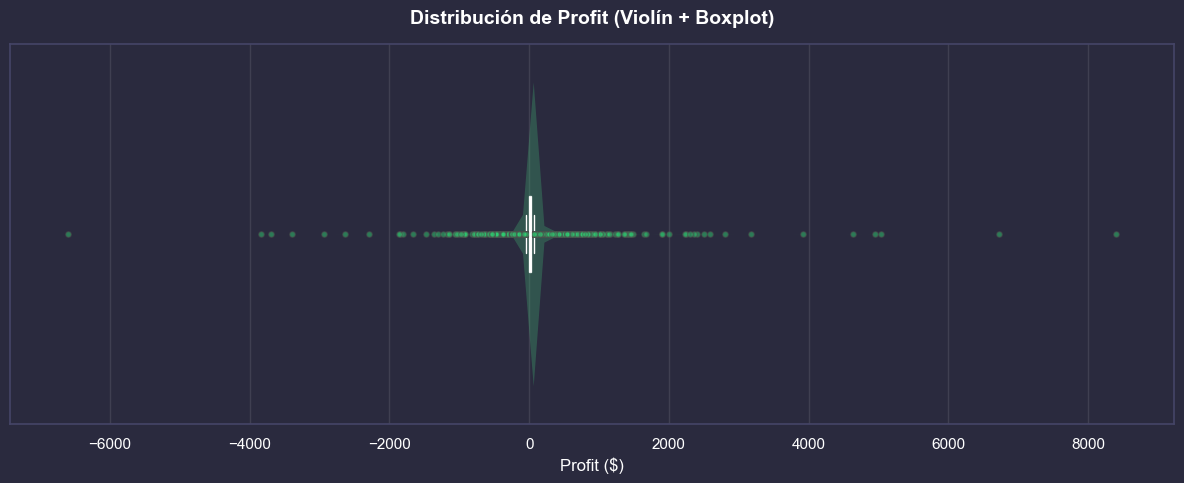

In [122]:
sns.set_theme(style="dark", rc={
    "axes.facecolor": "#2A2A3E", 
    "figure.facecolor": "#2A2A3E",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "axes.edgecolor": "#444466"
})

plt.figure(figsize=(12, 5))

# Violín (como fondo de la distribución)
sns.violinplot(x=data["Profit"].dropna(), color="#2ECC71", inner=None, alpha=0.3, linewidth=0)

#  Boxplot (encima del violín)
sns.boxplot(x=data["Profit"].dropna(), color="#2ECC71", width=0.2, boxprops=dict(edgecolor="white", alpha=0.8), whiskerprops=dict(color="white"), capprops=dict(color="white"),
    medianprops=dict(color="white", linewidth=2), flierprops=dict(marker="o", markerfacecolor="#2ECC71", markersize=4, alpha=0.5))

plt.title("Distribución de Profit (Violín + Boxplot)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Profit ($)")
plt.grid(axis='x', alpha=0.1) 
plt.tight_layout()
plt.show()

A partir del gráfico, se puede observar que la distribución de profit se encuentra centrada cerca de 0, lo que sugiere que muchas órdenes generan ganancias bajas o cercanas al punto de equilibrio. A su vez, podemos notar la presencia de valores negativos, que entendemos que representa la presencia de transacciones con pérdidas. 

Si bien presenta una alta concentración en torno a valores pequeños, evidenciando baja variabilidad en la mayoría de los casos, también se detectan algunos outliers tanto positivos como negativos, que se alejan considerablemente del resto de los datos.

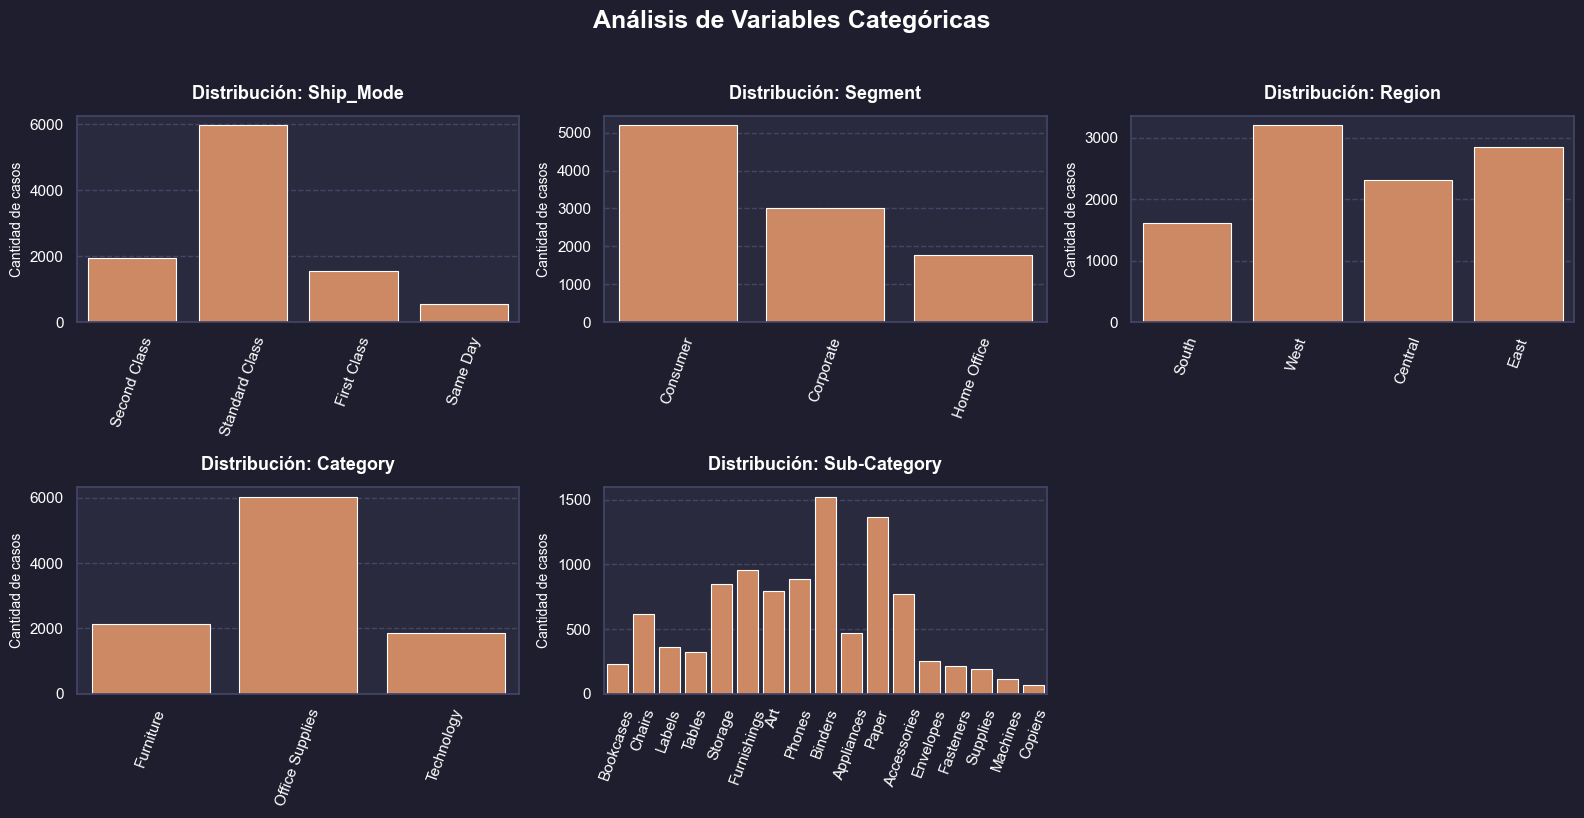

In [123]:
cols_categoricas = ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

color_cat = '#DD8452'
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor("#1E1E2E") 

axes = axes.flatten()

for i, col in enumerate(cols_categoricas):
    ax = axes[i]
    ax.set_facecolor("#2A2A3E")
    ax.grid(True, axis='y', color="#444466", linestyle="--", alpha=1, zorder=0)
    ax.set_axisbelow(True)
    
    sns.countplot(data=data, x=col, color=color_cat, ax=ax, edgecolor="white", linewidth=0.8)

    ax.set_title(f"Distribución: {col}", color="white", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad de casos", color="white", fontsize=10)
    ax.tick_params(axis='x', rotation=70, colors="white") 
    ax.tick_params(axis='y', colors="white")
    
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

# Ocultamos el útlimo gráfico
if len(cols_categoricas) < len(axes):
    for j in range(len(cols_categoricas), len(axes)):
        axes[j].set_visible(False)

plt.suptitle("Análisis de Variables Categóricas", color="white", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

A partir del gráfico podemos notar algunas propiedades de estas variables:
* `Ship_Mode`: Predomina claramente Standard Class, lo que indica que es el método de envío más utilizado. Same Day es muy poco frecuente.
* `Segment`: El segmento Consumer concentra la mayor cantidad de pedidos, seguido por Corporate y luego Home Office, mostrando un desbalance moderado.
* `Region`: La región West presenta la mayor cantidad de casos, mientras que South es la menos representada. La distribución es relativamente equilibrada.
* `Category`: Office Supplies domina ampliamente sobre Furniture y Technology, lo que indica una mayor frecuencia de ventas en esta categoría.
* `Sub-Category`: Se observa una alta variabilidad entre subcategorías. Algunas como Binders y Paper tienen alta frecuencia, mientras que otras como Copiers o Machines son poco comunes, evidenciando un fuerte desbalance.

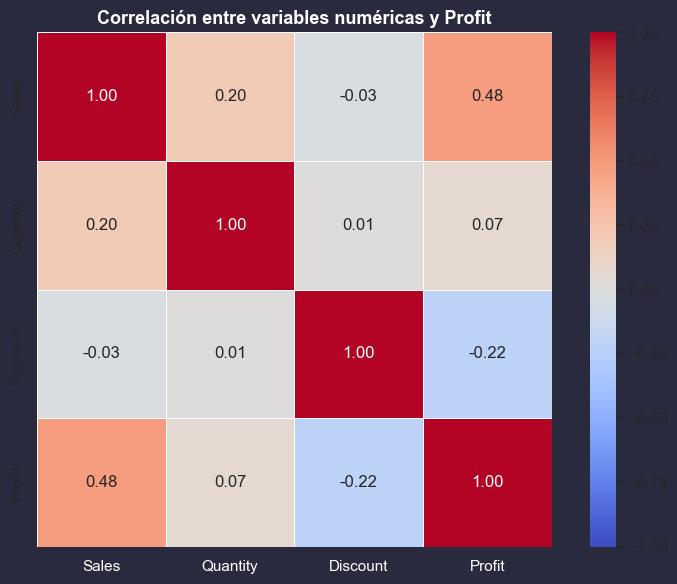

In [124]:
cols_numericas = ['Sales', 'Quantity', 'Discount', 'Profit']

corr_matrix = data[cols_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title("Correlación entre variables numéricas y Profit", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

A partir de la matriz de correlación, se observa que `Sales` es la variable que presenta la relación más clara con `Profit`, con una correlación positiva moderada (~0.48). Esto indica que, en general, a mayor volumen de ventas, mayor es la ganancia obtenida.

Por otro lado, `Discount` muestra una correlación negativa (~ -0.22), lo que sugiere que a medida que aumentan los descuentos, el beneficio tiende a disminuir. Este comportamiento es esperable y resulta relevante para el análisis, ya que los descuentos impactan directamente en la rentabilidad.

En cuanto a `Quantity`, la correlación con `Profit` es muy baja (~0.07), lo que indica que la cantidad de productos vendidos no tiene una relación lineal significativa con la ganancia.

En conjunto, estos resultados muestran que `Sales` y `Discount` son las variables más influyentes sobre `Profit`, mientras que `Quantity` aporta menor información en términos de relación directa.

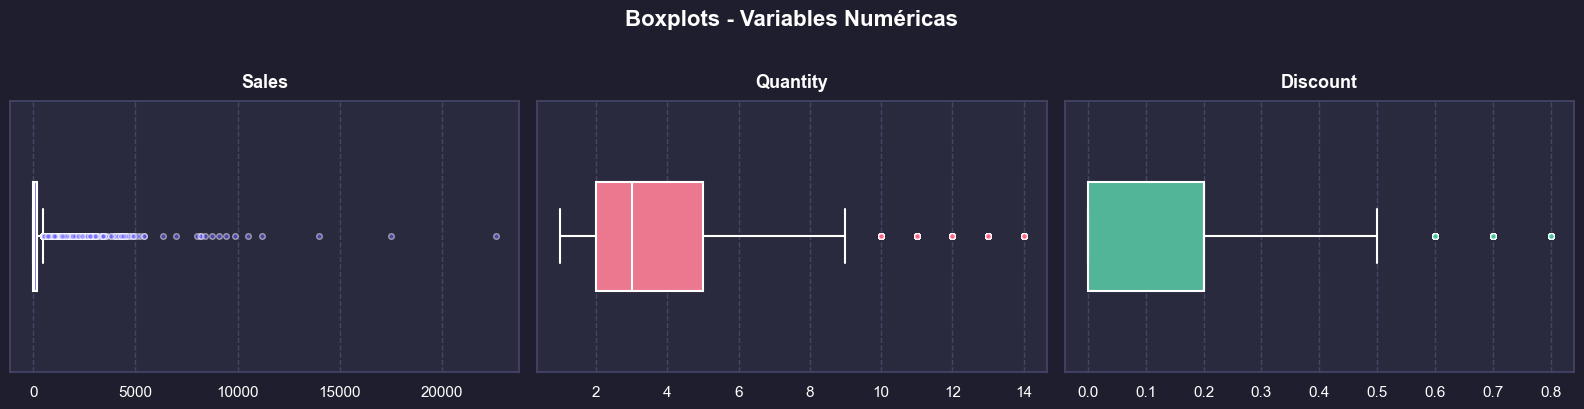

In [125]:
palette = ["#6C63FF", "#FF6584", "#43C59E", "#FFB347", "#4FC3F7"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#1E1E2E")
axes = axes.flatten()

for i, col in enumerate(['Sales', 'Quantity', 'Discount']):
    ax = axes[i]
    color = palette[i % len(palette)]

    
    ax.grid(True, axis='x', color="#444466", linestyle="--", alpha=1, zorder=0)
    ax.set_axisbelow(True) 

    sns.boxplot(x=data[col].dropna(), ax=ax, color=color, linecolor="white", linewidth=1.5, flierprops=dict(marker="o", markerfacecolor=color, markersize=4, alpha=0.5), width=0.4)

    ax.set_facecolor("#2A2A3E")
    ax.set_title(col, color="white", fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("")
    ax.tick_params(colors="white")
    ax.yaxis.label.set_color("white")
    
    for spine in ax.spines.values():
        spine.set_edgecolor("#444466")

plt.suptitle("Boxplots - Variables Numéricas", color="white", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

A partir de los boxplots de las variables numéricas, se pueden observar las siguientes características:

En el caso de `Sales`, se evidencia una distribución fuertemente sesgada a la derecha, con una gran cantidad de valores atípicos (outliers). Esto indica que existen algunas ventas extremadamente altas en comparación con la mayoría de los datos, lo cual puede influir significativamente en el modelo.

Para `Quantity`, la distribución es más concentrada, aunque también presenta algunos outliers en valores altos. La mayoría de las observaciones se encuentran en un rango reducido, lo que sugiere menor variabilidad en comparación con `Sales`.

Por otro lado, `Discount` muestra una distribución acotada, con valores mayormente bajos y algunos outliers en niveles más altos de descuento. 


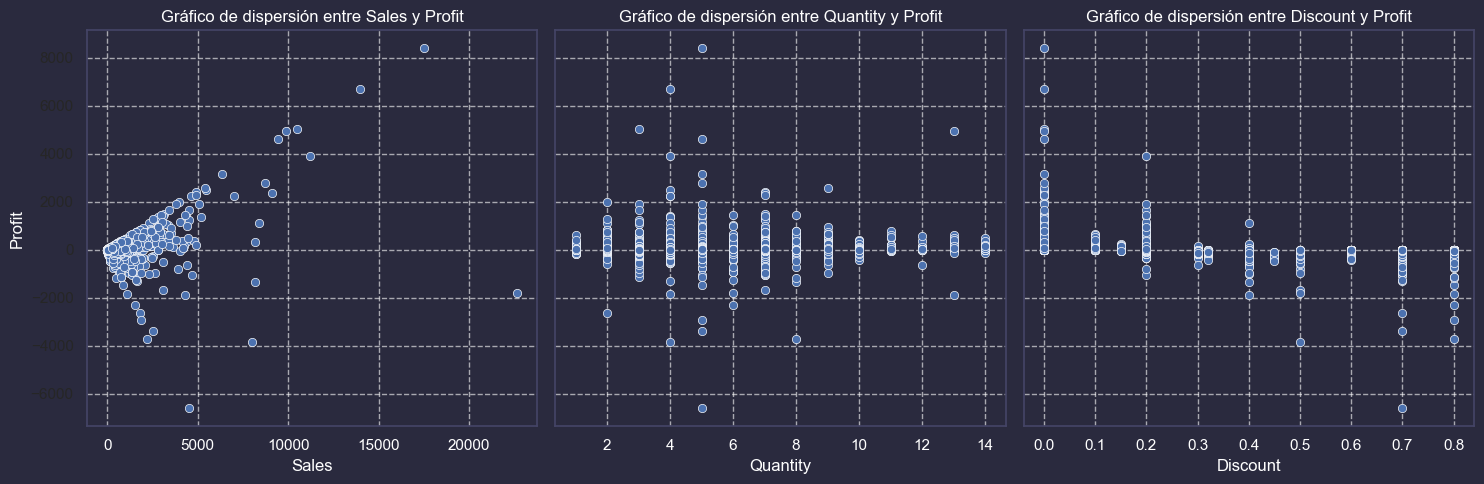

In [126]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, col in enumerate(['Sales', 'Quantity', 'Discount']):
    sns.scatterplot(data=data, x=col, y='Profit', ax=axes[i])
    axes[i].set_title(f'Gráfico de dispersión entre {col} y Profit')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Análisis de variables numéricas y Profit:

* Entre `Sales` y `Profit`:
    * Se observa una correlación positiva inicial; a mayores ventas, el potencial de ganancia aumenta.
    * Sin embargo, la dispersión se ensancha significativamente hacia la derecha, lo que confirma la presencia de valores atípicos que pueden derivar tanto en ganancias excepcionales como en pérdidas considerables.
* Entre `Quantity` y `Profit`:
    * La mayoría de las operaciones se concentran en un rango de beneficios cercano a cero, independientemente del volumen.
    * La distribución es más compacta en comparación con las ventas, aunque se aprecian puntos aislados de alta rentabilidad o pérdida en casi todos los niveles de cantidad.
* Entre `Discount` y `Profit`:
    * Existe una relación inversamente proporcional clara a partir de ciertos niveles.
    * Mientras los descuentos bajos (0% a 20%) mantienen márgenes positivos, el incremento de descuentos hacia el 80% (0.8) empuja la mayoría de las observaciones hacia el área de pérdidas, evidenciando un impacto crítico en el modelo de negocio.

# Preprocesamiento

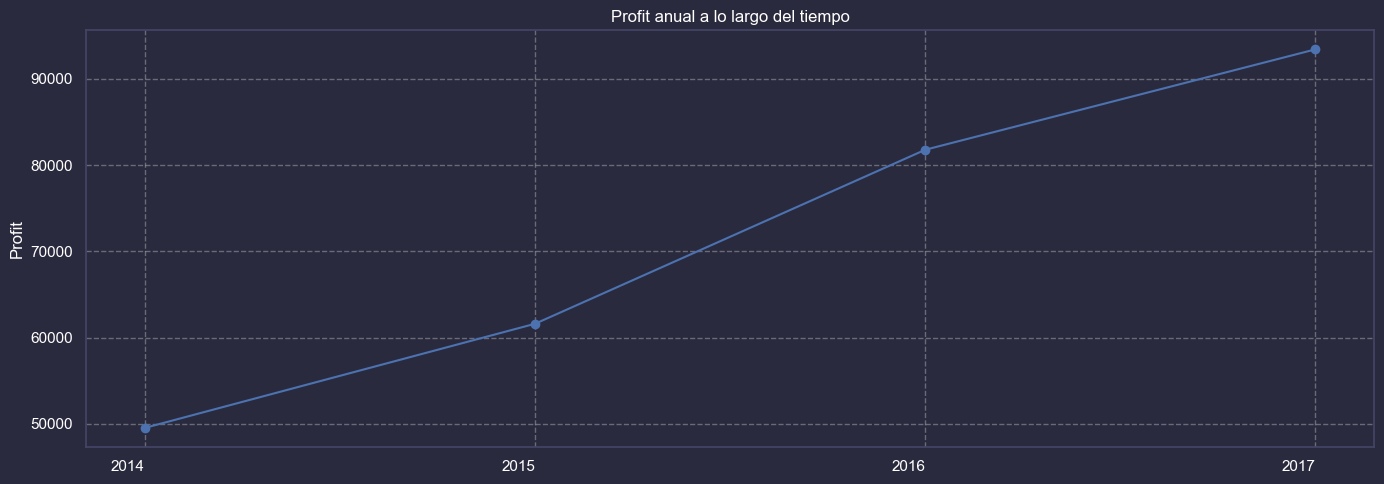

In [127]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True, format='mixed')  
data['Year'] = data['Order_Date'].dt.year
data['Month'] = data['Order_Date'].dt.month
data['Quarter'] = data['Order_Date'].dt.quarter

# Se agrupa el Profit por año
profit_mensual = data.groupby('Year')['Profit'].sum().reset_index()
profit_mensual['Year'] = profit_mensual['Year'].astype(str)
plt.figure(figsize=(14, 5))
plt.plot(profit_mensual['Year'], profit_mensual['Profit'], marker='o', linewidth=1.5)
plt.xticks(rotation=0, ha='right')
plt.title('Profit anual a lo largo del tiempo')
plt.ylabel('Profit', color='white')
plt.tick_params(axis='y', colors='white')
plt.tick_params(axis='x', colors='white')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

A partir del gráfico podemos notar que el valor de `Profit` acumulado muestra una tendencia creciente sostenida a lo largo de los 4 años, pasando de aproximadamente 50.000 a más de 90.000 dólares, lo que sugiere un crecimiento constante del negocio.

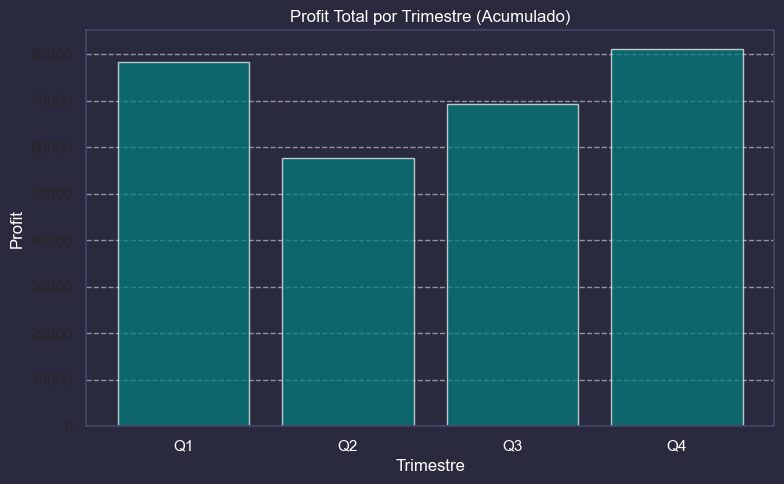

In [128]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True, format='mixed')
data['Quarter'] = data['Order_Date'].dt.quarter

# Se agrupa el Profit acumulado por trimestre
profit_por_trimestre = data.groupby('Quarter')['Profit'].sum().reset_index()
plt.figure(figsize=(8, 5))
plt.bar(profit_por_trimestre['Quarter'], profit_por_trimestre['Profit'], color='teal', alpha=0.7)
plt.title('Profit Total por Trimestre (Acumulado)')
plt.xlabel('Trimestre')
plt.ylabel('Profit')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4']) 
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

A partir del gráfico, se identifica que los picos de rentabilidad se concentran en los extremos del año, específicamente en el cuarto y primer trimestre. Por el contrario, el desempeño muestra una contracción significativa durante el segundo trimestre, el cual registra el valor de `Profit` más bajo de todo el periodo.

**Codificación de variables categóricas**

In [129]:
# Se realiza una codificación cíclica para el mes 
data['month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)

# Se definen las columnas para One-Hot Encoding
cols_onh = ['Ship_Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'Year', 'Quarter']

encoder = OneHotEncoder(drop='first', dtype=int, sparse_output=False)

encoded = encoder.fit_transform(data[cols_onh])
encoded_data = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cols_onh))

# Se dropean las columnas originales 
data = data.drop(columns=['Month', 'Order_Date', 'Ship_Date']).reset_index(drop=True)
data = data.drop(columns=cols_onh).reset_index(drop=True)

# Se concatenan los datasets
data = pd.concat([data, encoded_data], axis=1)

Técnicas utilizadas: 
* **Codificación cíclica** para `Month`: Se transforman los valores mensuales en coordenadas espaciales mediante funciones de seno y coseno. Esta técnica es fundamental para preservar la naturaleza periódica del tiempo, permitiendo que el modelo reconozca matemáticamente la proximidad entre diciembre (12) y enero (1), una relación que se perdería con una escala lineal simple.
* **One-Hot Encoding** para `variables categóricas`, `Year`, `Quarter`: Transforma categorías y periodos (Year, Quarter, YearMonth) en valores de 0 y 1 para que el modelo pueda procesarlos individualmente sin asumir un orden numérico falso.

**División en train y test**

In [130]:
X = data.drop('Profit', axis=1)
y = data['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [131]:
cols_escalar = ['Sales', 'Quantity', 'Discount']

scaler = RobustScaler()
scaler_y = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Se escala X
X_train_scaled[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_scaled[cols_escalar] = scaler.transform(X_test[cols_escalar])

# Se escala y
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Número de dimensiones
N_DIM = X_train_scaled.shape[1]

Se utiliza **RobustScaler** porque, a diferencia de otros escaladores, emplea la mediana y el rango intercuartílico en lugar de la media y la desviación estándar. De esta forma, se evita que los outliers, que ya habían sido identificados en las variables `Sales` y `Profit`, modifiquen el aprendizaje del modelo.

In [132]:
print(f"Train: {X_train_scaled.shape[0]} ejemplos ({X_train_scaled.shape[0]/len(data)*100:.0f}%)")
print(f"Test:  {X_test_scaled.shape[0]} ejemplos ({X_test_scaled.shape[0]/len(data)*100:.0f}%)")

Train: 6995 ejemplos (70%)
Test:  2999 ejemplos (30%)


# Diseño e implementación de la red neuronal y entrenamiento con sus curvas de aprendizaje.

In [133]:
def entrenar_pytorch_regresion(modelo, X_train, y_train, X_test, y_test, criterio_loss, epochs=200, batch_size=32, lr=1e-3, weight_decay=1e-4, patience=30):
    """
    Función de entrenamiento completa para regresión en PyTorch.
    Implementa el ciclo: Forward → Loss → Backward → Update
    con early stopping y registro de métricas por época.
    """
    
    X_tr = torch.tensor(X_train.values, dtype=torch.float32)
    y_tr = torch.tensor(y_train, dtype=torch.float32).squeeze() 
    X_te = torch.tensor(X_test.values,  dtype=torch.float32)
    y_te = torch.tensor(y_test,  dtype=torch.float32).squeeze() 

    dataset_train = TensorDataset(X_tr, y_tr)
    loader_train  = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    optimizador = optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)

    # Variables de seguimiento 
    historial = {'train_loss': [], 'test_loss': []}
    mejor_loss  = float('inf')
    mejor_pesos     = None
    epocas_sin_mejora = 0

    print(f"\n Iniciando entrenamiento PyTorch (Regresión)")
    print(f"   Épocas máximas: {epochs} | Batch size: {batch_size} | LR: {lr}")
    print(f"   Paciencia early stopping: {patience} épocas")
    print(f"   Batches por época: {len(loader_train)}")
    print("-" * 55)

    for epoca in range(epochs):

        modelo.train()
        loss_train_total = 0.0

        for X_batch, y_batch in loader_train:

            y_pred = modelo(X_batch)
            loss = criterio_loss(y_pred, y_batch)
            
            optimizador.zero_grad()
            loss.backward()
            optimizador.step()

            loss_train_total += loss.item()

        loss_train_promedio = loss_train_total / len(loader_train)

        
        modelo.eval()

        
        with torch.no_grad():
            y_pred_test = modelo(X_te)
            loss_test = criterio_loss(y_pred_test, y_te).item()

        historial['train_loss'].append(loss_train_promedio)
        historial['test_loss'].append(loss_test)

        
        if loss_test < mejor_loss:
            mejor_loss = loss_test

            mejor_pesos = {k: v.clone() for k, v in modelo.state_dict().items()}
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        if (epoca + 1) % 25 == 0:
            print(f"   Época {epoca+1:4d}/{epochs} | "
                  f"Loss train: {loss_train_promedio:.4f} | "
                  f"Loss test: {loss_test:.4f} | "
                  f"Sin mejora: {epocas_sin_mejora}/{patience}")

        if epocas_sin_mejora >= patience:
            print(f"\n   Early stopping en época {epoca+1}")
            print(f"   Mejor loss de validación: {mejor_loss:.4f}")
            break

    # Restaurar los mejores pesos
    if mejor_pesos is not None:
        modelo.load_state_dict(mejor_pesos)
        print(f"\n   Mejores pesos restaurados (loss test: {mejor_loss:.4f})")

    return historial

In [134]:
class RegresionNet_PyTorch(nn.Module):
    def __init__(self, input_dim=32, dropout_rate=0.3):
        super(RegresionNet_PyTorch, self).__init__()
        # Capa oculta 1: de input_dim features a 64 neuronas
        self.capa1 = nn.Linear(input_dim, 64)
        self.bn1   = nn.BatchNorm1d(64)    
        self.act1  = nn.ReLU()            
        self.drop1 = nn.Dropout(dropout_rate)  

        # Capa oculta 2: de 64 a 32 neuronas
        self.capa2 = nn.Linear(64, 32)
        self.bn2   = nn.BatchNorm1d(32)
        self.act2  = nn.ReLU()
        self.drop2 = nn.Dropout(dropout_rate)

        # Capa de salida: de 32 a 1 neurona, SIN activación (lineal)
        self.salida = nn.Linear(32, 1)

        self._inicializar_pesos()

    def _inicializar_pesos(self):
        """Aplica la inicialización de He a todas las capas lineales."""
        for modulo in self.modules():
            if isinstance(modulo, nn.Linear):
                nn.init.kaiming_normal_(modulo.weight, mode='fan_in', nonlinearity='relu')
                # El bias se inicializa en 0 (práctica estándar)
                nn.init.zeros_(modulo.bias)

    def forward(self, x):
        """
        forward: define el flujo de datos a través de la red.
        PyTorch llama a este método automáticamente cuando hacemos model(x).
        La propagación es: x → z1 → bn → relu → drop → z2 → bn → relu → drop → ŷ
        """
        # Capa 1: combinación lineal → normalización → activación → dropout
        x = self.capa1(x)    # z^[1] = W^[1] · x + b^[1]
        x = self.bn1(x)      # normalizar activaciones del batch
        x = self.act1(x)     # a^[1] = ReLU(z^[1])
        x = self.drop1(x)    # desactivar neuronas aleatoriamente

        # Capa 2: mismo patrón
        x = self.capa2(x)    # z^[2] = W^[2] · a^[1] + b^[2]
        x = self.bn2(x)
        x = self.act2(x)     # a^[2] = ReLU(z^[2])
        x = self.drop2(x)

        # Capa de salida: combinación lineal SIN activación
        x = self.salida(x)   # ŷ = W^[3] · a^[2] + b^[3]  (escalar)

        # squeeze(1) convierte de forma (batch, 1) a (batch,)
        return x.squeeze(1)

fijar_semillas(42)
# Instanciar el modelo
modelo_reg_pt = RegresionNet_PyTorch(input_dim=N_DIM, dropout_rate=0.2)
print("Arquitectura del modelo PyTorch para Regresión:")
print(modelo_reg_pt)

# Contar parámetros entrenables
total_params = sum(p.numel() for p in modelo_reg_pt.parameters() if p.requires_grad)
print(f"\nTotal de parámetros entrenables: {total_params:,}")
print(f"    Desglose por capa:")
for nombre, param in modelo_reg_pt.named_parameters():
    if param.requires_grad:
        forma_str = str(list(param.shape))
        print(f"     {nombre:30s} → {forma_str:20s} = {param.numel():5d} params")

Arquitectura del modelo PyTorch para Regresión:
RegresionNet_PyTorch(
  (capa1): Linear(in_features=37, out_features=64, bias=True)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU()
  (drop1): Dropout(p=0.2, inplace=False)
  (capa2): Linear(in_features=64, out_features=32, bias=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act2): ReLU()
  (drop2): Dropout(p=0.2, inplace=False)
  (salida): Linear(in_features=32, out_features=1, bias=True)
)

Total de parámetros entrenables: 4,737
    Desglose por capa:
     capa1.weight                   → [64, 37]             =  2368 params
     capa1.bias                     → [64]                 =    64 params
     bn1.weight                     → [64]                 =    64 params
     bn1.bias                       → [64]                 =    64 params
     capa2.weight                   → [32, 64]             =  2048 params
     capa2.bias

**Capas ocultas, neuronas y activaciones**: se utilizaron dos capas ocultas con 64 y 32 neuronas, formando una arquitectura decreciente (input→64→32→1) que permite comprimir progresivamente la información y capturar relaciones no lineales relevantes del problema. Como función de activación se eligió `ReLU()`, por su eficiencia computacional y su capacidad de mitigar el desvanecimiento del gradiente, en conjunto con la inicialización `He` (Kaiming Normal), que mantiene la estabilidad de las activaciones y favorece una convergencia más rápida.

**Función de activación en la capa de salida**: se implementa una capa nn.Linear(32, 1) sin función de activación, es decir, con una activación lineal (identidad). De esta forma, el modelo es capaz de predecir valores continuos tanto positivos como negativos para la variable objetivo (Profit).

**Optimizador, tasa de aprendizaje y estrategia de regularización**: se emplea el optimizador Adam con una tasa de aprendizaje de 1e-3, elegido por su capacidad de adaptar los momentos del gradiente individualmente por parámetro, lo que facilita la convergencia en paisajes de pérdida complejos. La estrategia de regularización es múltiple y robusta: se integra Batch Normalization para estabilizar la distribución interna de las activaciones y acelerar el aprendizaje; Dropout al 20% para evitar el sobreajuste forzando a la red a aprender representaciones redundantes; y una inicialización de sesgos en cero para comenzar el entrenamiento desde un punto neutral, asegurando que el modelo generalice correctamente ante la alta variabilidad del dataset.

In [135]:
criterios = {"MSE": nn.MSELoss(), "MAE": nn.L1Loss(), "Huber": nn.HuberLoss(delta=1)}
historiales = {}
modelos = {}

for nombre, criterio in criterios.items():
    
    print("-" * 55)
    print(f"Entrenando con {nombre}")

    modelo = RegresionNet_PyTorch(input_dim=N_DIM, dropout_rate=0.2)

    historial = entrenar_pytorch_regresion(
        modelo,
        X_train_scaled, y_train_scaled,
        X_test_scaled,  y_test_scaled,
        epochs=300,
        batch_size=64,
        lr=1e-3,
        weight_decay=1e-4,
        patience=30,
        criterio_loss=criterio
    )

    modelos[nombre] = modelo  
    historiales[nombre] = historial

-------------------------------------------------------
Entrenando con MSE

 Iniciando entrenamiento PyTorch (Regresión)
   Épocas máximas: 300 | Batch size: 64 | LR: 0.001
   Paciencia early stopping: 30 épocas
   Batches por época: 110
-------------------------------------------------------
   Época   25/300 | Loss train: 33.8555 | Loss test: 37.7896 | Sin mejora: 3/30
   Época   50/300 | Loss train: 20.2145 | Loss test: 15.4140 | Sin mejora: 1/30
   Época   75/300 | Loss train: 18.0328 | Loss test: 8.9739 | Sin mejora: 0/30
   Época  100/300 | Loss train: 12.5286 | Loss test: 16.2999 | Sin mejora: 11/30
   Época  125/300 | Loss train: 11.3087 | Loss test: 15.0505 | Sin mejora: 9/30
   Época  150/300 | Loss train: 10.9846 | Loss test: 13.4569 | Sin mejora: 14/30
   Época  175/300 | Loss train: 10.7751 | Loss test: 14.3644 | Sin mejora: 24/30

   Early stopping en época 181
   Mejor loss de validación: 5.4202

   Mejores pesos restaurados (loss test: 5.4202)
--------------------------

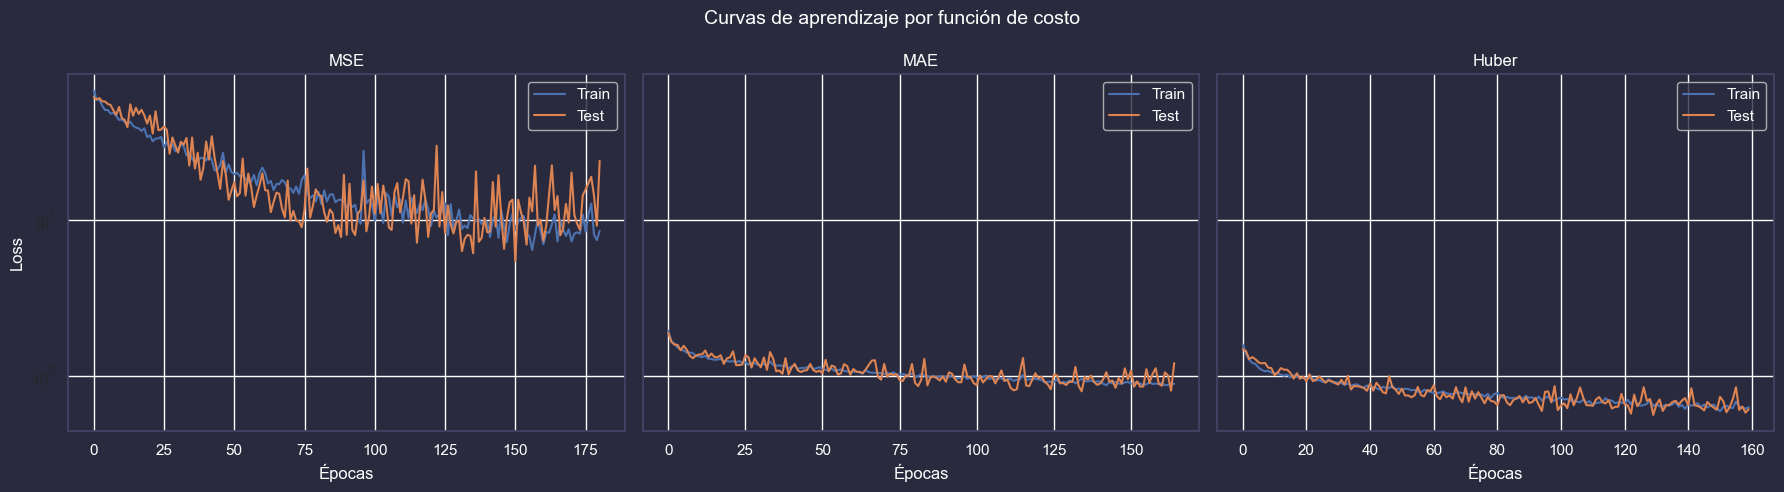

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

criterios_nombres = ["MSE", "MAE", "Huber"]

for i, nombre in enumerate(criterios_nombres):
    ax = axes[i]
    hist = historiales[nombre]
    
    ax.plot(hist['train_loss'], label='Train')
    ax.plot(hist['test_loss'], label='Test')
    
    ax.set_title(f"{nombre}")
    ax.set_xlabel("Épocas")
    ax.set_yscale('log') 
    
    if i == 0:
        ax.set_ylabel("Loss")
    
    ax.grid(True)
    ax.legend()

plt.suptitle("Curvas de aprendizaje por función de costo", fontsize=14)
plt.tight_layout()
plt.show()

In [137]:
def evaluar_modelo(modelo, X_test_scaled, y_test_scaled, scaler_y):
    modelo.eval()

    with torch.no_grad():
        X = torch.tensor(np.asarray(X_test_scaled).astype(np.float32))
        y = np.asarray(y_test_scaled).astype(np.float32).reshape(-1, 1)

        y_pred = modelo(X).cpu().numpy()

    y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1,1))
    y_orig      = scaler_y.inverse_transform(y.reshape(-1,1))

    mse  = mean_squared_error(y_orig, y_pred_orig)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_orig, y_pred_orig)

    return mse, rmse, r2

resultados = {}
for nombre, modelo in modelos.items():
    mse, rmse, r2 = evaluar_modelo(modelo, X_test_scaled, y_test_scaled, scaler_y)

    resultados[nombre] = {"MSE": mse, "RMSE": rmse, "R2": r2}

    print('-'*55)
    print(f"{nombre}")
    print(f"   MSE:  {mse:.2f}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   R²:   {r2:.4f}")

mejor = max(resultados, key=lambda k: resultados[k]["R2"])
print(f"\nMejor modelo: {mejor}")

-------------------------------------------------------
MSE
   MSE:  4163.08
   RMSE: 64.52
   R²:   0.9222
-------------------------------------------------------
MAE
   MSE:  12907.38
   RMSE: 113.61
   R²:   0.7588
-------------------------------------------------------
Huber
   MSE:  8022.68
   RMSE: 89.57
   R²:   0.8501

Mejor modelo: MSE


**Elección de la función de pérdida**: si bien se evaluaron tres funciones de costo (MSE, MAE y Huber), se seleccionó MSE (Mean Squared Error) como función principal debido a su mejor desempeño, obteniendo el menor MSE, el menor RMSE y el mayor coeficiente de determinación (R²), superando ampliamente a MAE y Huber en capacidad predictiva. 

MSE penaliza de manera más fuerte los errores grandes al elevarlos al cuadrado, lo que resulta beneficioso en este problema ya que permite ajustar mejor predicciones alejadas del valor real. En contraste, MAE trata todos los errores de forma lineal y Huber suaviza el impacto de los outliers, lo que puede reducir la sensibilidad del modelo frente a desviaciones importantes.

Entonces, si bien, las curvas de aprendizaje de las tres funciones muestran que las pérdidas de train y test convergen de forma consistente a lo largo del entrenamiento, lo que indica que el modelo generaliza correctamente. Decidimos optar por MSE, dado que el objetivo es maximizar la precisión global del modelo y explicar la mayor proporción de la varianza del Profit.

# Evaluación del modelo, análisis de residuos y conclusiones

Evaluación del Modelo PyTorch en Test (Regresión):
   MSE:  4163.08
   RMSE: 64.52  ($)
   R²:   0.9222


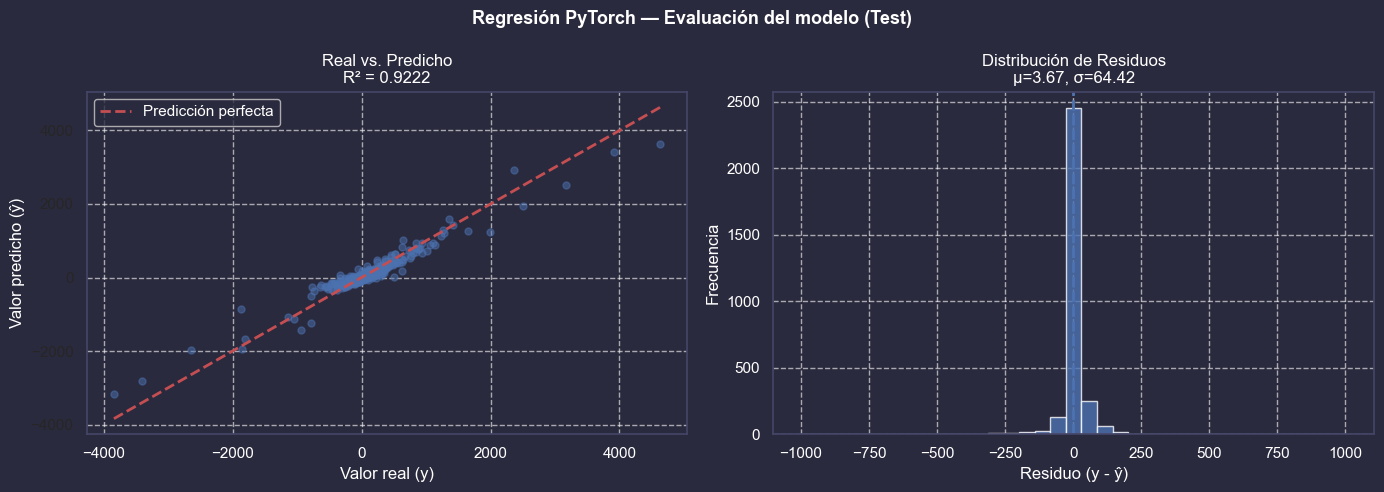

In [138]:
modelo_eval = modelos[mejor]
modelo_eval.eval()

with torch.no_grad():
    
    # Cargamos explícitamente los datos de TEST
    X_test_np = X_test_scaled.values if hasattr(X_test_scaled, "values") else X_test_scaled
    y_test_np = y_test_scaled.values if hasattr(y_test_scaled, "values") else y_test_scaled

    X_test_np = np.asarray(X_test_np).astype(np.float32)
    y_test_np = np.asarray(y_test_np).astype(np.float32)

    y_test_np = y_test_np.reshape(-1, 1)

    X_test_tensor = torch.tensor(X_test_np)

    y_pred_norm = modelo_eval(X_test_tensor).cpu().numpy()

# Invertimos el escalado para tener resultados interpretables
y_pred_original = scaler_y.inverse_transform(y_pred_norm.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test_np.reshape(-1, 1))

# Métricas contra Test
mse  = mean_squared_error(y_test_original, y_pred_original)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_original, y_pred_original)

print("Evaluación del Modelo PyTorch en Test (Regresión):")
print(f"   MSE:  {mse:.2f}")
print(f"   RMSE: {rmse:.2f}  ($)")
print(f"   R²:   {r2:.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regresión PyTorch — Evaluación del modelo (Test)', fontsize=13, fontweight='bold')

# Scatter (Real vs Predicho)
axes[0].scatter(y_test_original, y_pred_original, alpha=0.5, s=25)
rango = [min(y_test_original.min(), y_pred_original.min()), max(y_test_original.max(), y_pred_original.max())]
axes[0].plot(rango, rango, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('Valor real (y)')
axes[0].set_ylabel('Valor predicho (ŷ)')
axes[0].set_title(f'Real vs. Predicho\nR² = {r2:.4f}')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# Residuos
residuos = y_test_original - y_pred_original
axes[1].hist(residuos, bins=35, alpha=0.8, edgecolor='white')
axes[1].axvline(0, linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuo (y - ŷ)')
axes[1].yaxis.label.set_color('white')   
axes[1].tick_params(axis='y', colors='white')  
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_ylabel('Frecuencia')
axes[1].set_title(f'Distribución de Residuos\nμ={residuos.mean():.2f}, σ={residuos.std():.2f}')

plt.tight_layout()

**Métricas sobre el conjunto de test e interpretación en términos del negocio**: El modelo alcanzó un R² = 0.9222, un RMSE = 64.52 y un MSE = 4163.08. Esto significa que la arquitectura explica más del 92% de la variabilidad del Profit, lo cual representa un desempeño elevado para un problema con alta volatilidad inherente. En términos de negocio, el RMSE implica que, en promedio, las predicciones se desvían aproximadamente ±64 dólares del valor real. Para transacciones de bajo margen esto puede ser significativo, pero en operaciones de mayor escala (cientos o miles de dólares de profit) representa un error aceptable. 

**Análisis de residuos**: El histograma de residuos presenta una distribución centrada cerca de cero (μ = 3.67, σ = 64.42), lo que confirma que el modelo no introduce sesgo, es decir, no sobreestima ni subestima de forma constante ya que la mayoría de los errores se concentra en un rango estrecho, sin patrones de divergencia marcados. Sin embargo, tanto las colas del histograma como la mayor dispersión visible en el gráfico Real vs. Predicho para valores extremos indican que el modelo tiende a cometer errores más grandes cuando el Profit es muy alto o muy bajo. Como consecuencia de que estos casos son poco frecuentes en el dataset, y por ende, la red tiene menos oportunidades de aprenderlos correctamente. En definitiva, el modelo predice con precisión las transacciones habituales, pero pierde fiabilidad en operaciones de Profit excepcionalmente alto o bajo.

# Conclusión

El MLP implementado demostró ser una solución eficaz para la predicción de Profit, alcanzando un R² de 0.9222 con una arquitectura relativamente simple de dos capas ocultas (64 y 32 neuronas). Esto evidencia que no es necesaria una red profunda ni costosa computacionalmente para capturar las relaciones no lineales presentes en los datos, lo que convierte a este modelo en una opción práctica y equilibrada para el problema planteado.

Sin embargo, una limitación relevante de los MLP es su falta de interpretabilidad: si bien el modelo predice con precisión, no permite entender de forma directa qué variables impulsan el Profit ni cómo interactúan entre sí. En un contexto de negocio, esta opacidad puede ser un obstáculo cuando se requiere justificar decisiones o comunicar resultados a stakeholders no técnicos.

Por ello, como alternativa a considerar, los modelos basados en árboles de decisión —como Random Forest o Gradient Boosting (XGBoost, LightGBM)— ofrecen un nivel de interpretabilidad nativo significativamente mayor, a través de métricas de importancia de variables y estructuras de decisión auditables, manteniendo al mismo tiempo un desempeño competitivo en datos tabulares. Su adopción permitiría no solo predecir el Profit con precisión comparable, sino también extraer conclusiones accionables sobre los factores que más lo determinan.